In [1]:
import numpy as np
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix

In [55]:
N = 5000 # number of birds
L = 32 # size of a box
alpha = 0.15 # rate of random change
v = 2 # speed of bird
dt = 0.1
num_iter = 800

In [56]:
def generate_positions(birds_num: int = N, box_size: int = L):
    return np.random.rand(N, 2) * L

In [57]:
def generate_orientation(birds_num: int = N):
    return np.deg2rad(np.random.rand(N) * 360)

In [58]:
def step(position: np.ndarray,
         orientation: np.ndarray,
         alpha: float,
         v: float,
         N: int,
         L: int):
    
    birds_tree = cKDTree(position,boxsize=[L,L]) 
    rows, cols = birds_tree.sparse_distance_matrix(birds_tree,max_distance=1,output_type='coo_matrix').nonzero()
    
    # cos = np.cos(orientation)
    # sin = np.sin(orientation)
    # cos_sum = np.zeros(N)
    # sin_sum = np.zeros(N)

    # np.add.at(cos_sum, rows, cos[cols])
    # np.add.at(sin_sum, rows, sin[cols])
    
    # new_theta = np.arctan2(sin_sum, cos_sum) + alpha * np.random.rand(N)

    exp = np.exp(orientation*1j)
    exp_sum = np.zeros_like(exp)
    np.add.at(exp_sum, rows, exp[cols])
    
    new_theta = np.arctan2(np.imag(exp_sum), np.real(exp_sum)) + alpha * np.random.rand(N)

    angles = np.transpose([np.cos(new_theta), np.sin(new_theta)])
    new_position = position + v * angles * dt
    new_position = new_position - L *(new_position // L)
    return new_position, new_theta

In [59]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
position = generate_positions()
orientation = generate_orientation()

In [60]:
def angle_to_colors(orientation):
    normalized = (orientation % (2 * np.pi)) / (2 * np.pi)
    return plt.cm.hsv(normalized) 

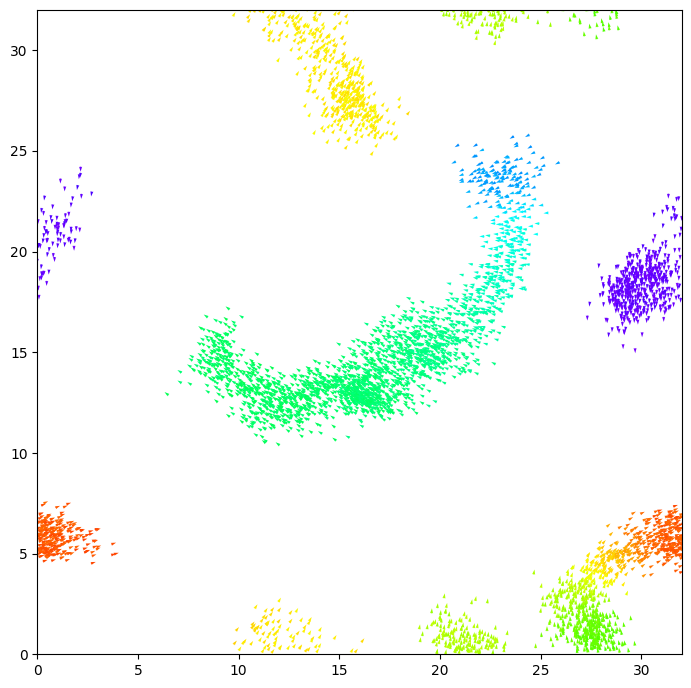

In [61]:
position = generate_positions()
orientation = generate_orientation()
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_aspect('equal')

colors = angle_to_colors(orientation)
quiver = ax.quiver(
    position[:, 0], position[:, 1],
    np.cos(orientation), np.sin(orientation),
    color=colors
)

def update(frame):
    global position, orientation
    position, orientation = step(position, orientation, alpha, v, N, L)
    colors = angle_to_colors(orientation)
    quiver.set_offsets(position)
    quiver.set_UVC(np.cos(orientation), np.sin(orientation))
    quiver.set_color(colors)   
    return quiver,

anim = animation.FuncAnimation(fig, update, frames=num_iter, interval=40, blit=True)
plt.tight_layout()
anim.save("birds.mp4", writer="ffmpeg", fps=20)
plt.show()